# 01 — Analyse exploratoire des données (EDA)

**Contexte :** une entreprise de télécommunications veut comprendre le comportement de ses clients et détecter ceux qui risquent de résilier leur abonnement.

**Variable cible :** `Churn` (Yes / No).

**Objectif de ce notebook :** comprendre les données, repérer les problèmes de qualité et identifier les variables liées au churn. À la fin, on produit une liste de décisions pour le preprocessing (J3).

> **Règle :** ici on *observe* seulement. Aucune imputation, aucun scaling, aucun encodage ajusté sur le dataset complet (risque de data leakage). Ces étapes iront dans un `Pipeline` après le split train/test.

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

# Chemin : le notebook est dans notebooks/, les données dans data/raw/
DATA_PATH = "../data/raw/wa-fn-usec-telco-customer-churn.csv"
PALETTE = {"No": "#4C72B0", "Yes": "#C44E52"}

## 2. Chargement des données

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Inspection générale

In [3]:
print("Dimensions :", df.shape)
print("Doublons (lignes entières) :", df.duplicated().sum())
print("customerID unique :", df["customerID"].is_unique)
df.info()

Dimensions : (7043, 21)
Doublons (lignes entières) : 0
customerID unique : True
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          70

**Lecture :** 7043 clients, 21 colonnes, aucun doublon. `customerID` est un simple identifiant : il sera retiré avant la modélisation.
`TotalCharges` apparaît en type texte (`object`/`str`) alors qu'elle devrait être numérique : on regarde pourquoi à la section suivante.

## 4. Qualité des données

### 4.1 Valeurs manquantes

In [4]:
print("NaN déclarés :")
print(df.isna().sum()[lambda s: s > 0] if df.isna().any().any() else "Aucun NaN déclaré par pandas")

# Cases vides déguisées (espaces) dans les colonnes texte
blank = {c: (df[c].astype(str).str.strip() == "").sum() for c in df.select_dtypes(exclude="number").columns}
print("\nCases vides cachées :", {k: v for k, v in blank.items() if v > 0})

NaN déclarés :
Aucun NaN déclaré par pandas

Cases vides cachées : {'TotalCharges': np.int64(11)}


`TotalCharges` contient des espaces vides : pandas ne les voit pas comme des NaN. On les inspecte.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")  # conversion de type uniquement, pas d'imputation
missing_tc = df[df["TotalCharges"].isna()]
print("Lignes avec TotalCharges manquant :", len(missing_tc))
missing_tc[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Lignes avec TotalCharges manquant : 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


**Lecture :** les 11 lignes concernées ont toutes `tenure = 0` : ce sont des nouveaux clients qui n'ont pas encore été facturés, aucun n'a churné. Ce n'est donc pas une erreur aléatoire mais un cas logique : `TotalCharges` vaut **0** dans ce cas.
**Décision (J3) :** imputer par 0 (ou laisser un imputer dans le Pipeline). Avec 11 lignes sur 7043 (0,16 %), l'impact est minime.

### 4.2 Cohérence des modalités

In [6]:
cat_cols = df.select_dtypes(exclude="number").columns.drop(["customerID", "Churn"]).tolist()
pd.DataFrame({c: [sorted(df[c].unique())] for c in cat_cols}).T.rename(columns={0: "modalités"})

,modalités
gender,"[Female, Male]"
Partner,"[No, Yes]"
Dependents,"[No, Yes]"
PhoneService,"[No, Yes]"
MultipleLines,"[No, No phone service, Yes]"
InternetService,"[DSL, Fiber optic, No]"
OnlineSecurity,"[No, No internet service, Yes]"
OnlineBackup,"[No, No internet service, Yes]"
DeviceProtection,"[No, No internet service, Yes]"
TechSupport,"[No, No internet service, Yes]"


**Lecture :** les colonnes de services (`OnlineSecurity`, `TechSupport`, etc.) ont une modalité `No internet service`, et `MultipleLines` a `No phone service`. Elles sont redondantes avec `InternetService` / `PhoneService`. On pourra les fusionner avec `No` au preprocessing.
`SeniorCitizen` est codée 0/1 alors que les autres binaires sont Yes/No : à harmoniser.

In [7]:
# Vérification de la redondance
chk = df[df["InternetService"] == "No"][["OnlineSecurity", "TechSupport", "StreamingTV"]].nunique()
print("Clients sans internet : modalités distinctes par colonne de service ->", chk.to_dict())

Clients sans internet : modalités distinctes par colonne de service -> {'OnlineSecurity': 1, 'TechSupport': 1, 'StreamingTV': 1}


## 5. Analyse de la variable cible

          n     %
Churn            
No     5174  73.5
Yes    1869  26.5


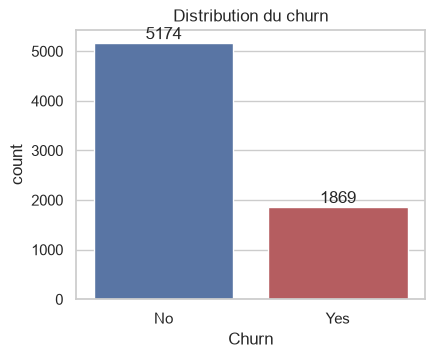

In [8]:
counts = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"n": counts, "%": pct}))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(data=df, x="Churn", hue="Churn", palette=PALETTE, legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
ax.set_title("Distribution du churn")
plt.show()

**Lecture :** environ 26,5 % de churn : le jeu de données est **déséquilibré** (ratio ~ 2,8 : 1).
**Conséquences :** l'accuracy seule sera trompeuse (un modèle qui prédit toujours "No" aurait ~73 %). On utilisera Recall, F1, ROC-AUC, un split **stratifié**, et `class_weight` / SMOTE dans le Pipeline.

In [9]:
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)  # utilisé seulement pour calculer des taux de churn
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

## 6. Analyse univariée

### 6.1 Variables numériques

In [10]:
df[num_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


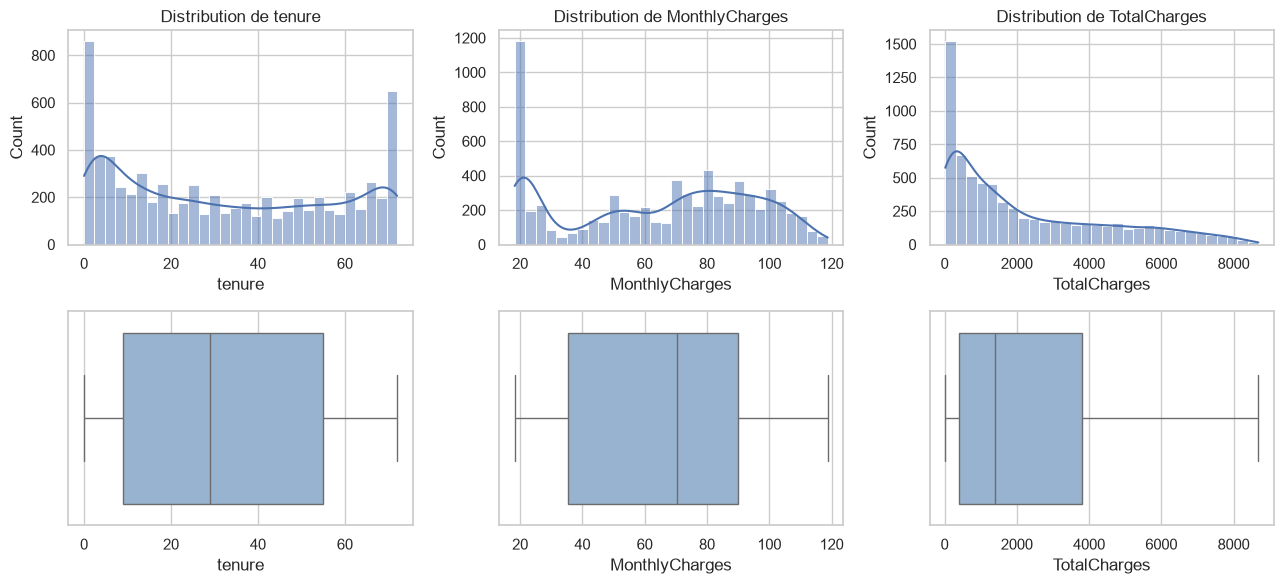

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), bins=30, kde=True, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(f"Distribution de {c}")
    sns.boxplot(x=df[c], ax=axes[1, i], color="#8FB3D9")
plt.tight_layout()
plt.show()

In [12]:
# Outliers par la règle de l'IQR
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    print(f"{c:15s} outliers (IQR) : {n_out}")

tenure          outliers (IQR) : 0
MonthlyCharges  outliers (IQR) : 0
TotalCharges    outliers (IQR) : 0


**Lecture :**
- `tenure` : distribution en "U" (beaucoup de clients très récents et beaucoup de très anciens).
- `MonthlyCharges` : bimodale (un groupe à faible facture, probablement sans internet, et un groupe plus élevé).
- `TotalCharges` : très asymétrique à droite (cumul croissant avec l'ancienneté).
- Aucun outlier selon l'IQR : les valeurs extrêmes de `TotalCharges` sont des clients anciens et chers, pas des erreurs. On les garde.

### 6.2 Variables catégorielles

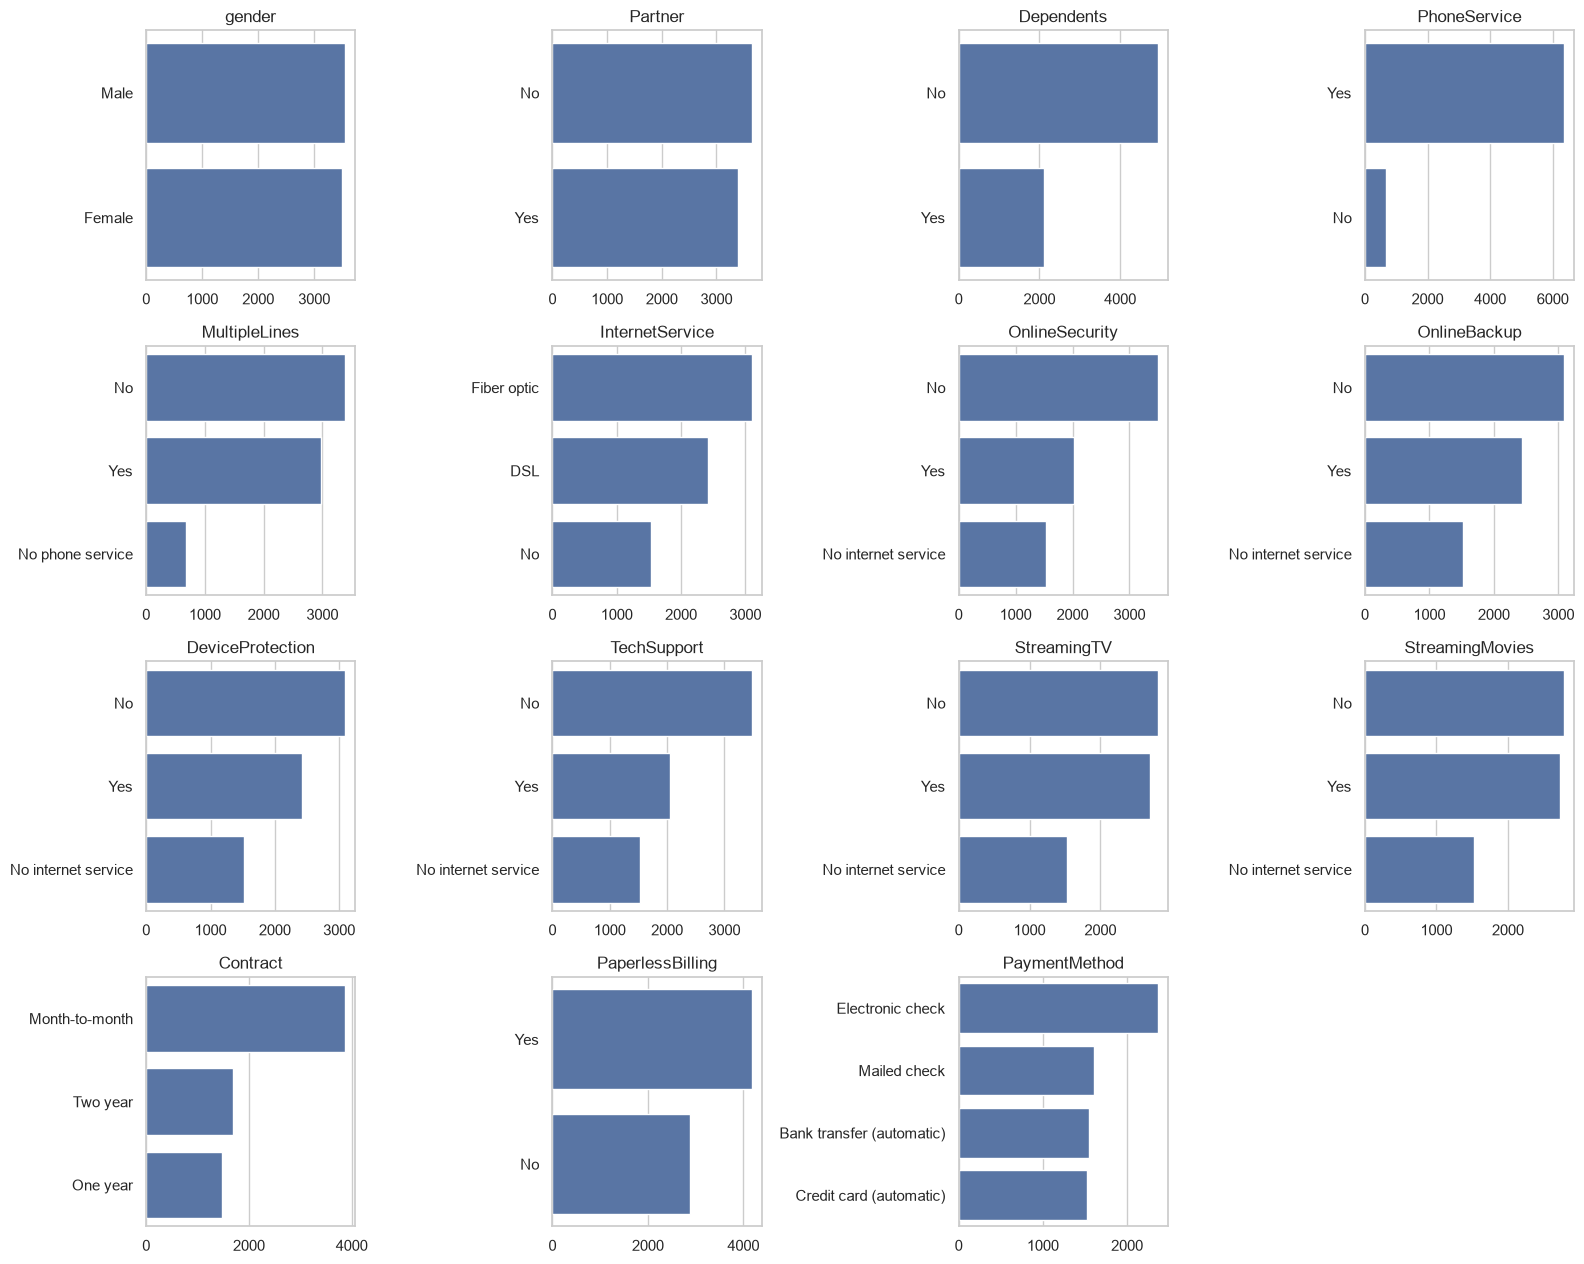

In [13]:
plot_cols = [c for c in cat_cols]
n = len(plot_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
for ax, c in zip(axes.ravel(), plot_cols):
    order = df[c].value_counts().index
    sns.countplot(data=df, y=c, order=order, ax=ax, color="#4C72B0")
    ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Lecture :** `gender`, `Partner`, `Dependents` sont assez équilibrées ; `PhoneService` est très majoritairement "Yes" ; `Contract` est dominé par le mensuel ; `SeniorCitizen` (non tracée ici car numérique 0/1) représente environ 16 % des clients.

## 7. Analyse bivariée : variables vs Churn

### 7.1 Variables numériques

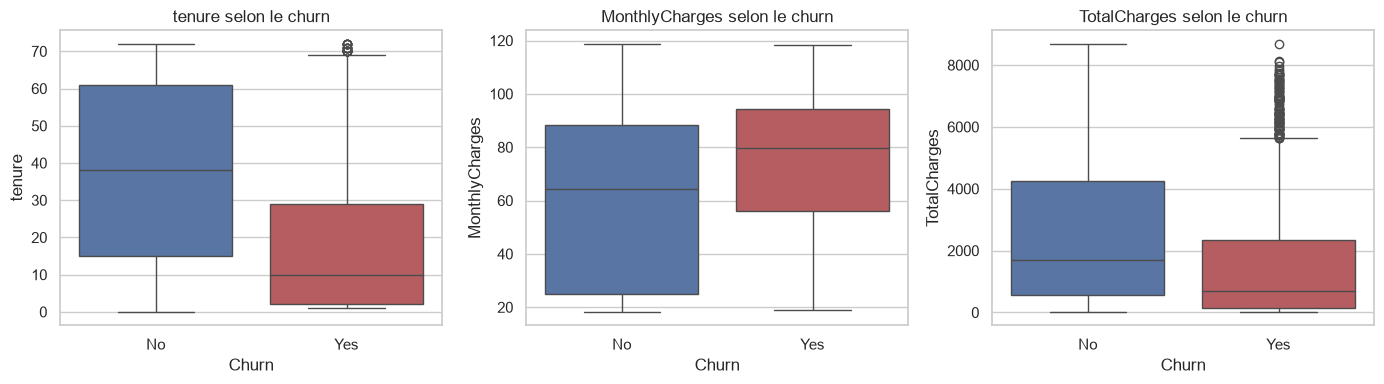

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.4,1683.6
Yes,10.0,79.6,703.6


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=c, hue="Churn", palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f"{c} selon le churn")
plt.tight_layout()
plt.show()

df.groupby("Churn")[num_cols].median().round(1)

**Lecture :** les clients qui partent ont une ancienneté (`tenure`) nettement plus faible et des `MonthlyCharges` plus élevées. `TotalCharges` est plus faible chez eux, surtout à cause de la faible ancienneté.

### 7.2 Variables catégorielles : taux de churn par modalité

In [15]:
cat_all = cat_cols + ["SeniorCitizen"]
rates = []
for c in cat_all:
    r = df.groupby(c)["Churn_bin"].mean().mul(100)
    for mod, val in r.items():
        rates.append({"variable": c, "modalité": str(mod), "churn_%": round(val, 1)})
rates = pd.DataFrame(rates)

# Écart de taux (max - min) pour classer les variables par pouvoir discriminant
spread = rates.groupby("variable")["churn_%"].agg(lambda s: s.max() - s.min()).sort_values(ascending=False)
spread.round(1).to_frame("écart de churn (points)")

,écart de churn (points)
variable,
Contract,39.9
InternetService,34.5
OnlineSecurity,34.4
TechSupport,34.2
OnlineBackup,32.5
DeviceProtection,31.7
PaymentMethod,30.1
StreamingMovies,26.3
StreamingTV,26.1


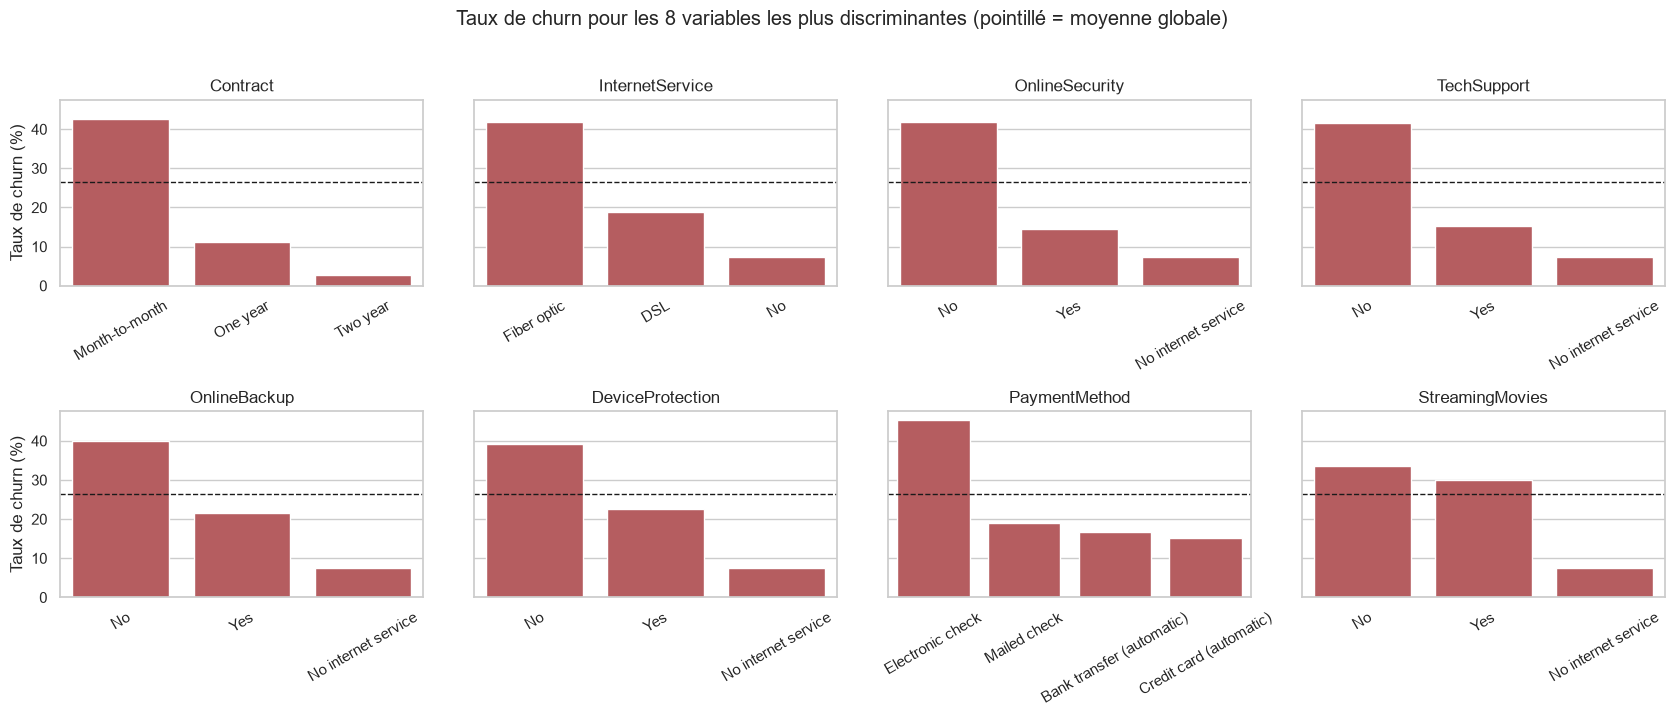

In [16]:
top = spread.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharey=True)
for ax, c in zip(axes.ravel(), top):
    r = df.groupby(c)["Churn_bin"].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=r.index.astype(str), y=r.values, ax=ax, color="#C44E52")
    ax.axhline(df["Churn_bin"].mean() * 100, color="k", ls="--", lw=1)
    ax.set_title(c); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
axes[0, 0].set_ylabel("Taux de churn (%)"); axes[1, 0].set_ylabel("Taux de churn (%)")
plt.suptitle("Taux de churn pour les 8 variables les plus discriminantes (pointillé = moyenne globale)", y=1.02)
plt.tight_layout()
plt.show()

**Lecture :**
- **Contrat** : le mensuel est de loin le plus risqué (~43 %), contre ~3 % pour le contrat de 2 ans.
- **Internet** : la fibre optique churne beaucoup plus que le DSL ; sans internet, le churn est très faible.
- **Services de protection** (`OnlineSecurity`, `TechSupport`) : ne pas les avoir augmente fortement le risque.
- **Paiement** : "Electronic check" ressort nettement.
- `gender` et `PhoneService` ont un écart quasi nul : variables peu informatives.

## 8. Corrélations et relations entre variables

### 8.1 Variables numériques

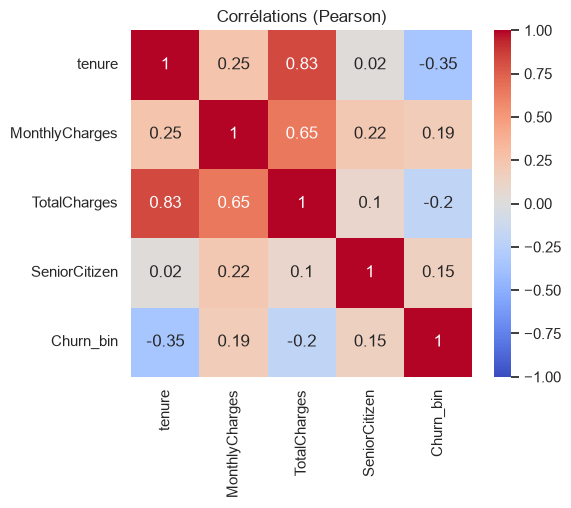

Corrélation TotalCharges vs tenure*MonthlyCharges : 1.0


In [17]:
corr = df[num_cols + ["SeniorCitizen", "Churn_bin"]].corr().round(2)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélations (Pearson)")
plt.show()

# Redondance TotalCharges ~ tenure x MonthlyCharges
approx = (df["tenure"] * df["MonthlyCharges"])
print("Corrélation TotalCharges vs tenure*MonthlyCharges :", round(df["TotalCharges"].corr(approx), 3))

**Lecture :** `TotalCharges` est très corrélée à `tenure` (~0,83) et quasiment égale à `tenure × MonthlyCharges` : information **redondante**. Elle peut poser problème pour les modèles linéaires et fausser les distances en clustering. À surveiller (garder une seule des variables ou en dériver une charge moyenne).
`tenure` est la variable numérique la plus (négativement) liée au churn.

### 8.2 Variables catégorielles (V de Cramér)

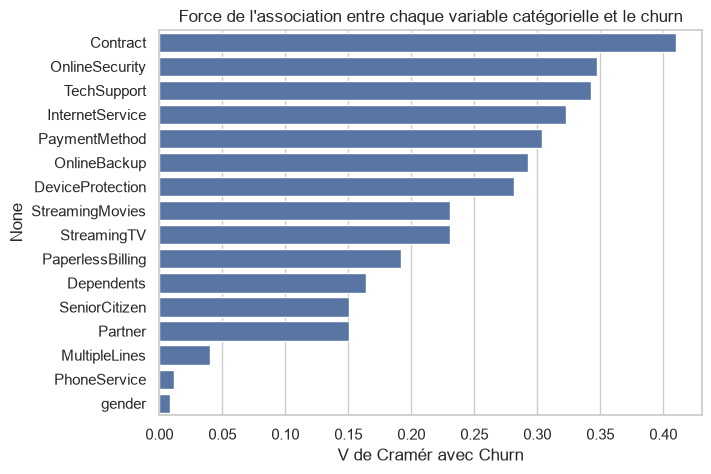

,V de Cramér
Contract,0.410
OnlineSecurity,0.347
TechSupport,0.343
InternetService,0.322
PaymentMethod,0.303
OnlineBackup,0.292
DeviceProtection,0.282
StreamingMovies,0.231


In [18]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cv = {c: cramers_v(df[c], df["Churn"]) for c in cat_all}
cv = pd.Series(cv).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=cv.values, y=cv.index, color="#4C72B0")
plt.xlabel("V de Cramér avec Churn")
plt.title("Force de l'association entre chaque variable catégorielle et le churn")
plt.show()
cv.round(3).head(8).to_frame("V de Cramér")

**Lecture :** `Contract`, `OnlineSecurity`, `TechSupport`, `InternetService` et `PaymentMethod` sont les plus associées au churn. `gender` et `PhoneService` sont proches de 0 : candidates à être retirées ou ignorées.

## 9. Pistes de Feature Engineering

Seulement des **idées testées de façon exploratoire** sur une copie. L'implémentation propre (dans le Pipeline) se fera en J3.

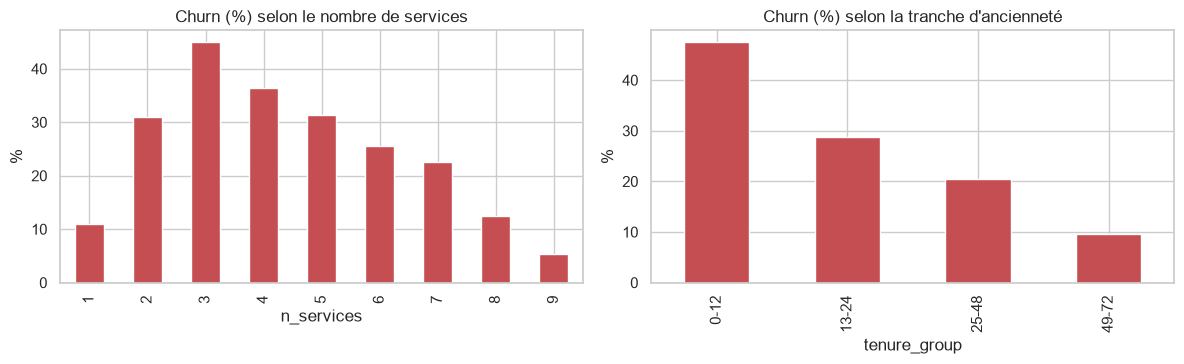

Écart moyen |avg_charge - MonthlyCharges| : 1.74


In [19]:
fe = df.copy()
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# 1) Nombre de services souscrits
fe["n_services"] = (fe[service_cols] == "Yes").sum(axis=1) + (fe["InternetService"] != "No").astype(int)

# 2) Charge moyenne mensuelle réelle (évite la division par 0 pour tenure = 0)
fe["avg_charge"] = np.where(fe["tenure"] > 0, fe["TotalCharges"] / fe["tenure"], fe["MonthlyCharges"])

# 3) Tranches d'ancienneté
fe["tenure_group"] = pd.cut(fe["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12", "13-24", "25-48", "49-72"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
fe.groupby("n_services")["Churn_bin"].mean().mul(100).plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Churn (%) selon le nombre de services"); axes[0].set_ylabel("%")
fe.groupby("tenure_group", observed=True)["Churn_bin"].mean().mul(100).plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Churn (%) selon la tranche d'ancienneté"); axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()

print("Écart moyen |avg_charge - MonthlyCharges| :", round((fe['avg_charge'] - fe['MonthlyCharges']).abs().mean(), 2))

**Lecture :** le churn décroît nettement avec l'ancienneté, ce qui valide le découpage en tranches. Le nombre de services a un lien **non monotone** avec le churn : il culmine autour de 3 services (~45 %) puis décroît, ce qui reflète le profil fibre sans options de protection ; un modèle d'arbre saura l'exploiter. La charge moyenne réelle diffère légèrement de `MonthlyCharges` (changements de tarif au cours du temps).

## 10. Synthèse et décisions pour le preprocessing 

| Sujet | Constat | Décision |
|---|---|---|
| Identifiant | `customerID` unique, sans valeur prédictive | Supprimer |
| `TotalCharges` | 11 vides, tous avec `tenure = 0` | Convertir en numérique, imputer par 0 (dans le Pipeline) |
| Modalités redondantes | "No internet service" / "No phone service" | Fusionner avec "No" |
| `SeniorCitizen` | Codée 0/1 | Traiter comme binaire, harmoniser |
| Variables binaires | Yes/No | Encodage 0/1 |
| Variables multi-modalités | `Contract`, `InternetService`, `PaymentMethod` | One-hot encoding |
| Numériques | `tenure`, `MonthlyCharges`, `TotalCharges` : échelles différentes, pas d'outliers | StandardScaler (après le split, dans le Pipeline) |
| Redondance | `TotalCharges` ≈ `tenure × MonthlyCharges` | Surveiller / éventuellement retirer ou remplacer par la charge moyenne |
| Variables peu informatives | `gender`, `PhoneService` | Candidates à retirer |
| Déséquilibre | ~26,5 % de churn | Split stratifié, `class_weight`, SMOTE dans le Pipeline, métriques Recall / F1 / ROC-AUC |
| Feature Engineering | Ancienneté, nombre de services, charge moyenne | `n_services`, `tenure_group`, `avg_charge` |
| Clustering | `Churn` interdit en entrée | Exclure `Churn` et `Churn_bin` des features |